1: Training Model

1.1 Importing Libraries

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import  DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error , mean_squared_error ,r2_score , accuracy_score
print("Libraries imported") 

Libraries imported


1.2 : Loading dataset

In [27]:
df = pd.read_csv('C:\\Users\\HP\\OneDrive\\Desktop\\Intern project\\Smart-Electricity-Consumption\\dataset\\processed_data.csv')
df.head(1)

,House_Type,Family_Members,Rooms,AC_Hours,Fan_Hours,Refrigerator,Washing_Machine_Hours,Water_Motor_Hours,Lighting_Hours,Outdoor_Temperature,Season,Day_Type,Work_From_Home,Solar_Panels,Daily_Electricity_Consumption
0,-1.033043,2.178954,-0.168969,0.177951,-0.352711,0.209383,-0.061826,-1.240197,1.127151,-0.154057,-0.436124,-0.150904,1.611559,2.038293,18.42


1.3: Seprating Feature and Target columns

In [28]:
X= df.drop('Daily_Electricity_Consumption',axis=1)
y= df['Daily_Electricity_Consumption']

1.4: Train_Test_Split

In [29]:
X_train , X_test , y_train , y_test = train_test_split(X, y , test_size=0.20, random_state=42)

print("Training sample",len(X_train))
print("Testing sample:" , len(y_test))

Training sample 400
Testing sample: 100


1.5: Training Model 1 (Linear Regression Model)

In [39]:
linear_model = LinearRegression()
linear_model.fit(X_train , y_train)
prediction = linear_model.predict(X_test)
lin_mae =  mean_absolute_error(y_test , prediction)
lin_mse = mean_squared_error(y_test , prediction)
lin_r2 = r2_score(y_test , prediction)
display("Linear Regression results")
print(f"Mean Absolute Error: {lin_mae:.2f}")
print(f"Mean Sqaured Error: {lin_mse:.2f}")
print(f"r2_Score: {lin_r2:.2f}")


'Linear Regression results'

Mean Absolute Error: 0.56
Mean Sqaured Error: 0.45
r2_Score: 0.99


1.6 : Training model 2 (Decision Tree)

In [37]:
des_model = DecisionTreeRegressor()
des_model.fit(X_train , y_train)
des_prediction  = des_model.predict(X_test)
des_mae=mean_absolute_error(y_test , des_prediction)
des_mse = mean_squared_error(y_test , des_prediction)
des_r2 = r2_score(y_test , des_prediction)


In [34]:
print("Decision Tree Evaluation")
print(f"Mean Absolute Error :{des_mae:.2f} ")
print(f"Mean Squared Error: {des_mse:.2f}")
print(f"R2 Score : {des_r2:.2f}")

Decision Tree Evaluation
Mean Absolute Error :1.27 
Mean Squared Error: 2.73
R2 Score : 0.96


1.7: Model (3): Random Forest 

In [40]:
rf_model = RandomForestRegressor()
rf_model.fit(X_train , y_train)
rf_prediction = rf_model.predict(X_test)
rf_mae=mean_absolute_error(y_test , rf_prediction)
rf_mse = mean_squared_error(y_test , rf_prediction)
rf_r2 = r2_score(y_test , rf_prediction)


In [41]:
print("Random forest Evaluation")
print(f"Mean Absolute Error :{rf_mae:.2f} ")
print(f"Mean Squared Error: {rf_mse:.2f}")
print(f"R2 Score : {rf_r2:.2f}")

Random forest Evaluation
Mean Absolute Error :0.97 
Mean Squared Error: 1.56
R2 Score : 0.98


1.8: Comparison of results of model 

In [42]:
results = pd.DataFrame({
    "Model":["Linear Regression" , "Decision Tree" , "Random Forest"],
    "Mean Absolute Error": [lin_mae,des_mae,rf_mae],
    "Mean Squared Error": [des_mae,des_mse , des_r2],
    "R2 Score": [rf_mae, rf_mse , rf_r2]
})
results

,Model,Mean Absolute Error,Mean Squared Error,R2 Score
0,Linear Regression,0.562595,1.346100,0.970566
1,Decision Tree,1.346100,2.936661,1.562936
2,Random Forest,0.970566,0.960709,0.979089


1.9: Plotting graph

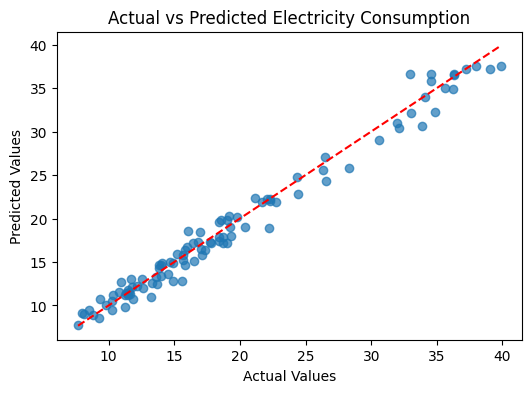

In [53]:
plt.figure(figsize=(6,4))
plt.scatter(
    y_test,
    rf_prediction,
    alpha = 0.7
)
plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    'r--'
)
plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted Electricity Consumption")

plt.show()

Insights: Linear Regression is the best model for us.

In [54]:
import joblib
joblib.dump(
    linear_model,
    "C:\\Users\\HP\\OneDrive\\Desktop\\Intern project\\Smart-Electricity-Consumption\\models\\best_model.pkl"
)
print("Model saved successfully")

Model saved successfully
